In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from imblearn.over_sampling import SMOTE

In [6]:

print("Dataset Head:\n", df.head())

print("\nDataset Info:\n")
df.info()


for col in df.columns:
    if df[col].dtype == 'object': 
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:  
        df[col].fillna(df[col].mean(), inplace=True)


label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  


print("\nProcessed Dataset Info:\n")
df.info()


Dataset Head:
          id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_wo

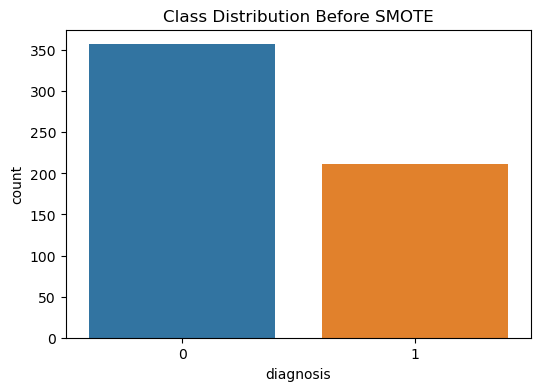

In [7]:

plt.figure(figsize=(6, 4))
sns.countplot(x=df['diagnosis']) 
plt.title("Class Distribution Before SMOTE")
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


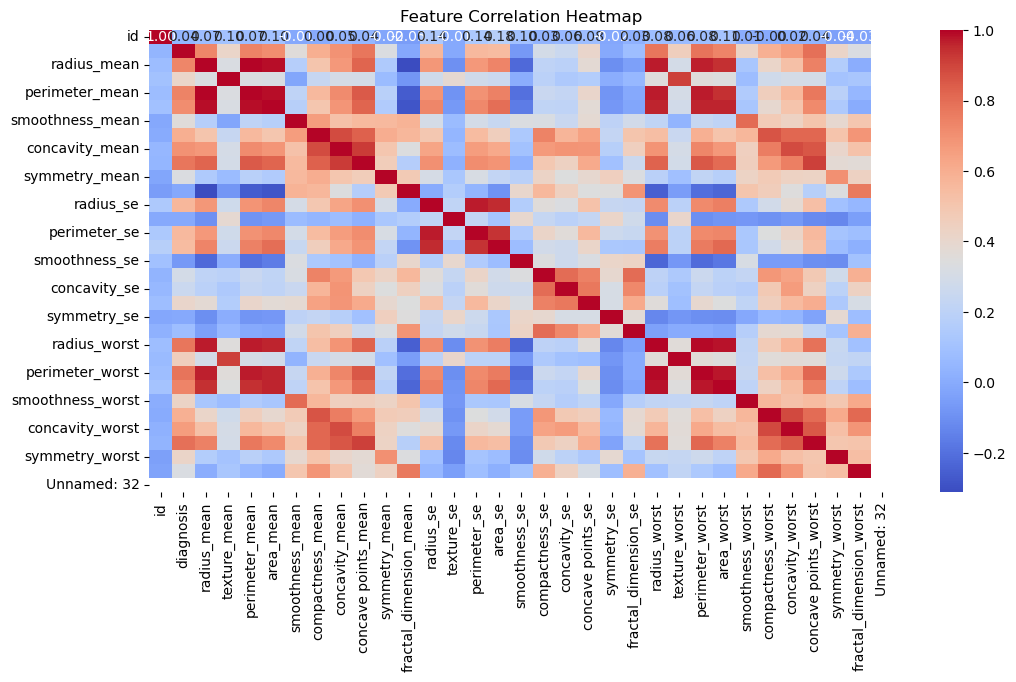

In [8]:

plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


In [10]:

correlation = df.corr()['diagnosis'].abs().sort_values(ascending=False)
selected_features = correlation[1:11].index  

X = df[selected_features]
y = df['diagnosis']

smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [11]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

X_reshaped = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))

X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

In [29]:

baseline_model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(X_train.shape[1], 1)),
    Dense(1, activation='sigmoid')  
])

baseline_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

baseline_history = baseline_model.fit(X_train, y_train, epochs=30, batch_size=64, validation_data=(X_test, y_test), verbose=0)

y_pred_baseline = (baseline_model.predict(X_test) > 0.5).astype("int32")
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print(f"\nBaseline Model Accuracy: {baseline_accuracy:.8f}")

C:\Users\91636\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/stepWARNING:tensorflow:5 out of the last 26 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000026A189EAA20> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

Baseline Model Accuracy: 0.93006993


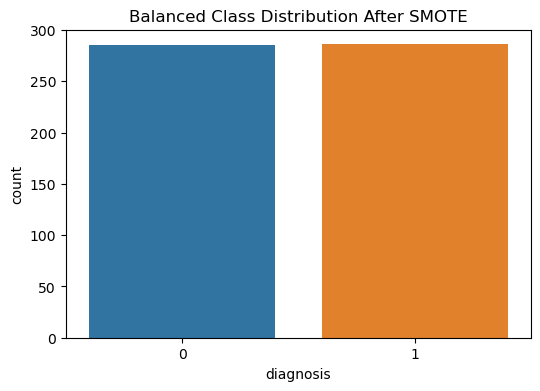

In [12]:

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train)
plt.title("Balanced Class Distribution After SMOTE")
plt.show()

In [30]:

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(64, return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(32),
    BatchNormalization(),
    Dropout(0.2),

    Dense(25, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy', metrics=['accuracy'])


early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, min_lr=1e-5)

history = model.fit(X_train, y_train, epochs=100, batch_size=64, validation_data=(X_test, y_test),
                    callbacks=[early_stopping, reduce_lr], verbose=0)

y_pred_improved = (model.predict(X_test) > 0.5).astype("int32")
improved_accuracy = accuracy_score(y_test, y_pred_improved)

print(f"\nBaseline Model Accuracy: {baseline_accuracy:.4f}")
print(f"Improved Model Accuracy: {improved_accuracy:.4f}")


C:\Users\91636\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step

Baseline Model Accuracy: 0.9301
Improved Model Accuracy: 0.9510


In [16]:


y_pred = (model.predict(X_test) > 0.5).astype("int32")

accuracy = accuracy_score(y_test, y_pred)
print(f"Improved Model Accuracy: {accuracy:.4f}")

print("\nClassification Report:\n", classification_report(y_test, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step
Improved Model Accuracy: 0.9301

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.97      0.93        72
           1       0.97      0.89      0.93        71

    accuracy                           0.93       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.93      0.93      0.93       143



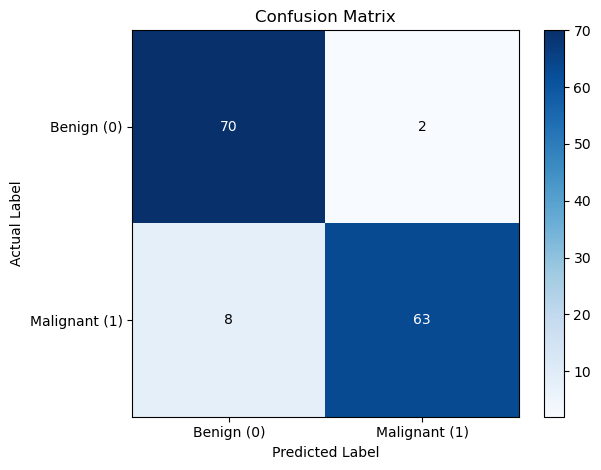

In [19]:

conf_matrix = confusion_matrix(y_test, y_pred)

plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, labels=["Benign (0)", "Malignant (1)"], rotation=0)
plt.yticks(tick_marks, labels=["Benign (0)", "Malignant (1)"])


thresh = conf_matrix.max() / 2.
for i, j in np.ndindex(conf_matrix.shape):
    plt.text(j, i, format(conf_matrix[i, j], 'd'),
             ha="center", va="center",
             color="white" if conf_matrix[i, j] > thresh else "black")

plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

